In [1]:
import numpy as np 
import meep as mp 
import matplotlib.pyplot as plt
import meep.adjoint as mpa
import os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
dir = 'data4transmission'
dir1 = f"{dir}/data"
dir2 = f"{dir}/figure"
os.makedirs(dir1, exist_ok=True)
os.makedirs(dir2, exist_ok=True)

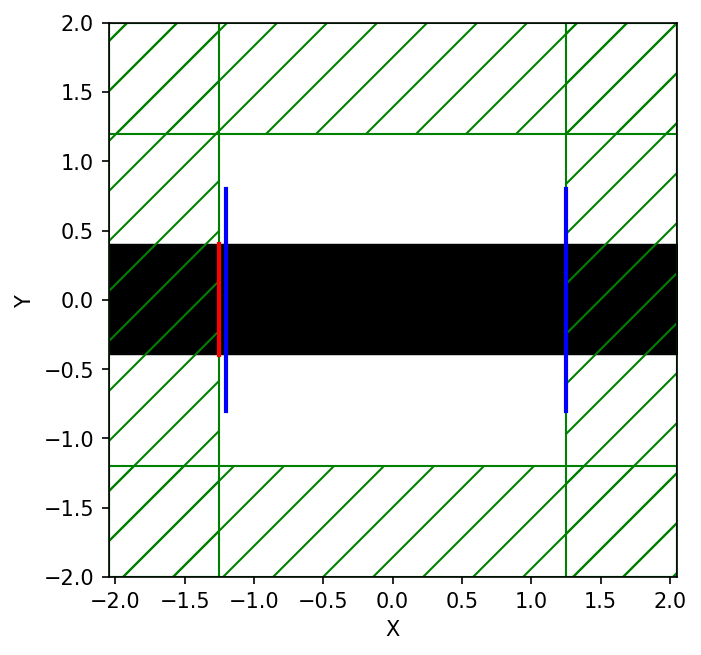

In [3]:
design = np.load("data/final_design.npy")


# %%
mp.verbosity(0)
Air = mp.Medium(index=1)
Si = mp.Medium(index=3.48)
resolution = 250

dx = 2.4  # design_region_x_width = 1    
dy = 0.8  # design_region_y_width = 1   
pml_size = 0.8
air_size = 0.8
Sx = dx + 2*pml_size + 0.1

Sy = dy + 2*pml_size + 2*air_size
cell_size = mp.Vector3(Sx, Sy)
# === 設計區尺寸與 cavity 區 ===
Nx = int(dx * resolution) + 1 
Ny = int(dy * resolution) + 1

design_2d = design.reshape(Nx,Ny)

# === Mapping 參數 ===
minimum_length = 0.02
eta_i = 0.5
eta_e = 0.55
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
pml_layers = [mp.PML(thickness=pml_size)]

# %%
# Design frequency
wavelengths = np.array([1.55])
frequencies = np.array([1 / 1.55])
fcen = 1. / 1.55
df = 0.2
source_center = mp.Vector3(-Sx/2+pml_size,0) 
# source_center1 = mp.Vector3(-Sx/2+pml_size+0.8,0) 
src_size = dy 
source_size = mp.Vector3(0,src_size) 
src = mp.GaussianSource(frequency=fcen, fwidth=df)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
pml_layers = [mp.PML(thickness=pml_size)]

# %%

design_variables = mp.MaterialGrid(
mp.Vector3(Nx, Ny), 
medium1=Air,
medium2=Si,
weights=design_2d,
grid_type="U_MEAN"
)

design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(0,0,0),
        size=mp.Vector3(dx, dy,0),
    ),
)
geometry = [ 
    mp.Block(center=mp.Vector3(), size=mp.Vector3(Sx,dy), material=Si),    
]

sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    resolution=resolution,
    extra_materials=[Si],
)


nfreq = 100  # number of frequencies at which to compute flux

# reflected flux
refl_fr = mp.FluxRegion(
    center=mp.Vector3(-0.5 * Sx + pml_size + 0.05, 0, 0), size=mp.Vector3(0, 2 *dy, 0)
)
refl = sim.add_flux(fcen, df, nfreq, refl_fr)

# transmitted flux
tran_fr = mp.FluxRegion(
    center=mp.Vector3(0.5 * Sx - pml_size, 0, 0), size=mp.Vector3(0, 2 * dy, 0)
)
tran = sim.add_flux(fcen, df, nfreq, tran_fr)

plt.figure(dpi=150)
sim.plot2D()
plt.show()

In [4]:
pt = mp.Vector3(0.5 * Sx - pml_size - 0.05, 0)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ey, pt, 1e-3))

# for normalization run, save flux fields data for reflection plane
straight_refl_data = sim.get_flux_data(refl)

In [5]:
# save incident power for transmission plane
straight_tran_flux = mp.get_fluxes(tran)

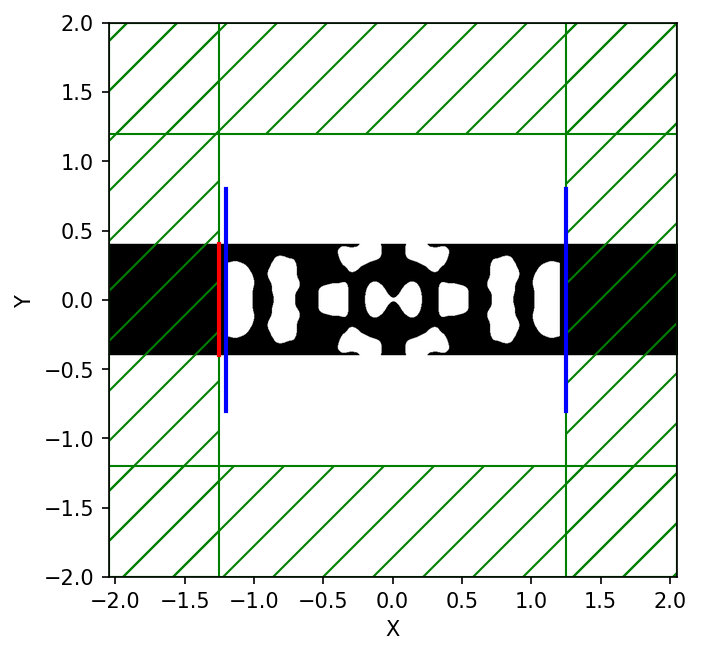

In [6]:
sim.reset_meep()

geometry = [ 
    mp.Block(center=mp.Vector3(), size=mp.Vector3(Sx,dy), material=Si),
    mp.Block(center=mp.Vector3(), size=design_region.size, material=design_variables),
]    


sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    resolution=resolution,
    extra_materials=[Si],
)


nfreq = 100  # number of frequencies at which to compute flux

# reflected flux
refl_fr = mp.FluxRegion(
    center=mp.Vector3(-0.5 * Sx + pml_size + 0.05, 0, 0), size=mp.Vector3(0, 2 *dy, 0)
)
refl = sim.add_flux(fcen, df, nfreq, refl_fr)

# transmitted flux
tran_fr = mp.FluxRegion(
    center=mp.Vector3(0.5 * Sx - pml_size, 0, 0), size=mp.Vector3(0, 2 * dy, 0)
)
tran = sim.add_flux(fcen, df, nfreq, tran_fr)
sim.load_minus_flux_data(refl, straight_refl_data)

plt.figure(dpi=150)
sim.plot2D()
plt.show()

In [7]:
pt = mp.Vector3(0.5 * Sx - pml_size - 0.05, 0)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ey, pt, 1e-3))

bend_refl_flux = mp.get_fluxes(refl)
bend_tran_flux = mp.get_fluxes(tran)

flux_freqs = mp.get_flux_freqs(refl)

In [8]:
# === Compute wavelength and normalized R, T ===
flux_freqs = np.array(flux_freqs)
wl = 1 / flux_freqs
fs = flux_freqs
Rs = -np.array(bend_refl_flux) / np.array(straight_tran_flux)
Ts =  np.array(bend_tran_flux) / np.array(straight_tran_flux)

# === 儲存資料 ===
np.save(f"{dir1}/wl.npy", wl)
np.save(f"{dir1}/fs.npy", fs)
np.save(f"{dir1}/Rs.npy", Rs)
np.save(f"{dir1}/Ts.npy", Ts)



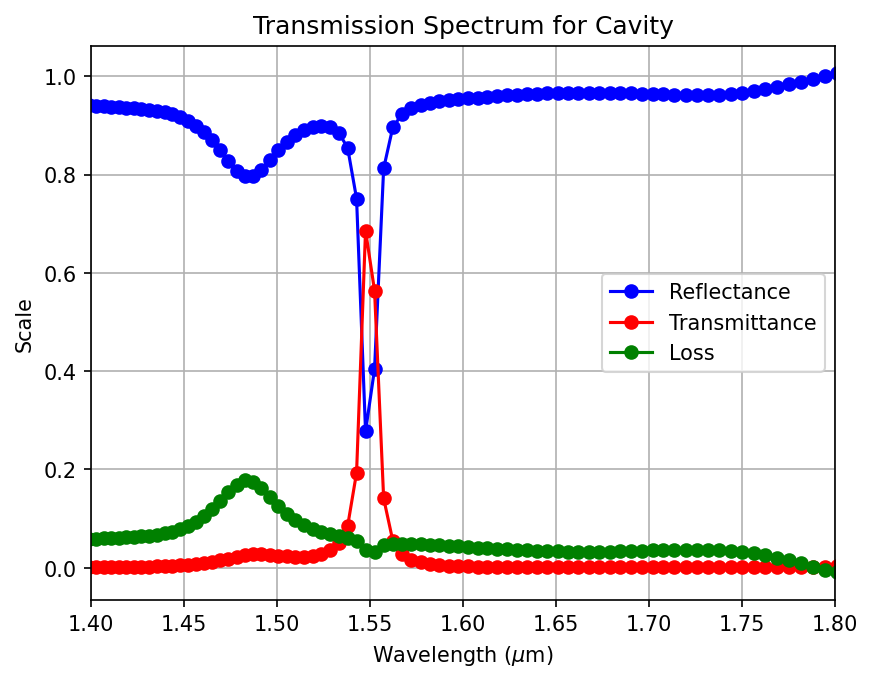

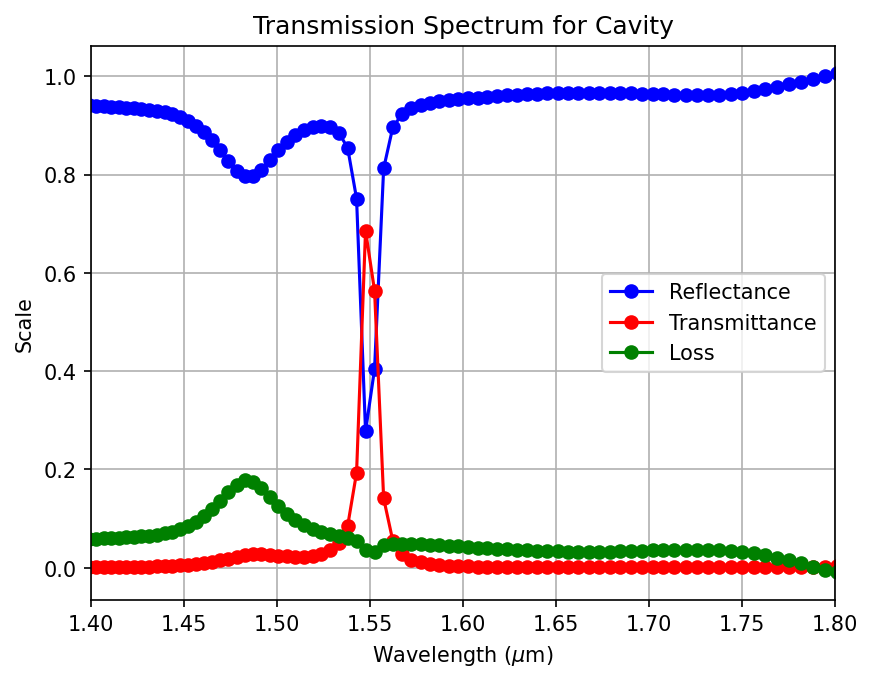

In [9]:
def plot_spectrum_wl(wl, Rs, Ts, save_path, transparent=True):
    if mp.am_master():
        plt.figure(dpi=150)
        plt.plot(wl, Rs, "bo-", label="Reflectance")
        plt.plot(wl, Ts, "ro-", label="Transmittance")
        plt.plot(wl, 1 - Rs - Ts, "go-", label="Loss")
        plt.xlim(1.4, 1.8)
        plt.xlabel(r"Wavelength ($\mu\mathrm{m}$)")
        plt.ylabel("Scale")
        plt.grid()
        plt.legend(loc="best")
        plt.title("Transmission Spectrum for Cavity")
        plt.savefig(save_path, transparent=transparent)
        plt.show()
        plt.close()
plot_spectrum_wl(wl, Rs, Ts, f"{dir2}/figure4cavity_spectrum.png", transparent=True)
plot_spectrum_wl(wl, Rs, Ts, f"{dir2}/figure4cavity_spectrum_background_fill.png", transparent=False)


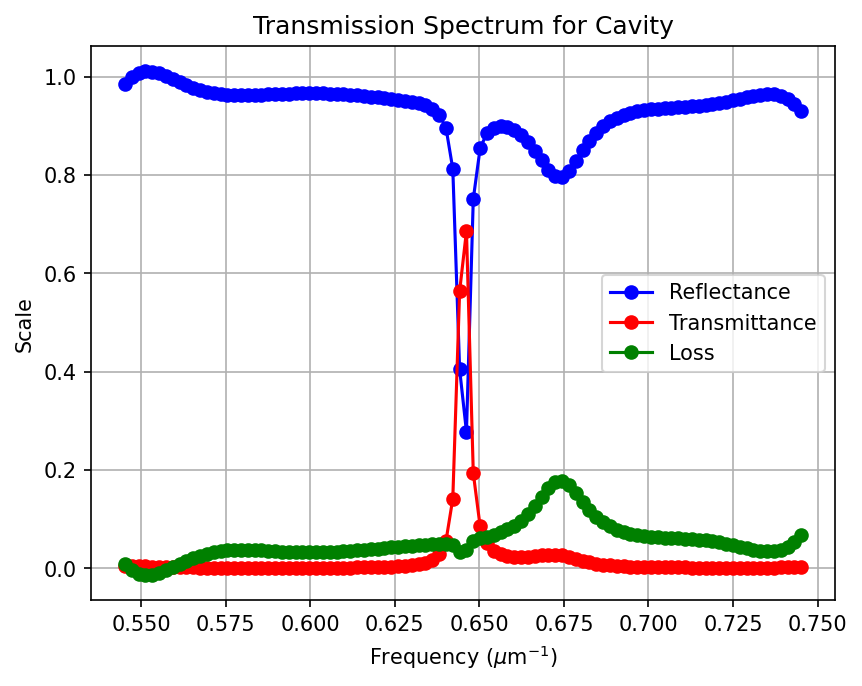

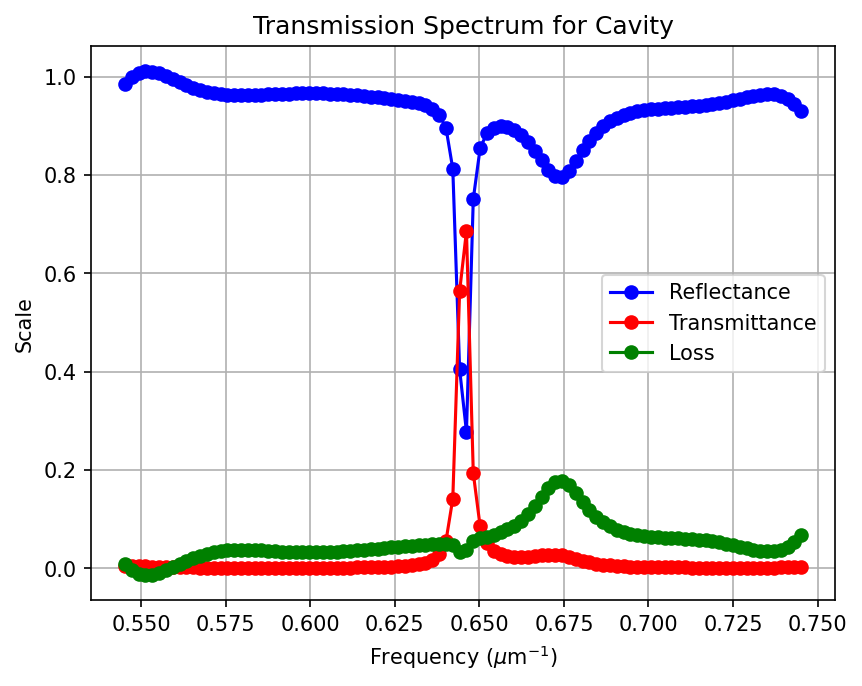

In [10]:
def plot_spectrum_fs(fs, Rs, Ts, save_path, transparent=True):
    if mp.am_master():
        plt.figure(dpi=150)
        plt.plot(fs, Rs, "bo-", label="Reflectance")
        plt.plot(fs, Ts, "ro-", label="Transmittance")
        plt.plot(fs, 1 - Rs - Ts, "go-", label="Loss")
        # Optional axis limits
        # plt.xlim(fcen - df/2, fcen + df/2)

        plt.xlabel(r"Frequency ($\mu\mathrm{m}^{-1}$)")
        plt.ylabel("Scale")
        plt.grid()
        plt.legend(loc="best")
        plt.title("Transmission Spectrum for Cavity")
        plt.savefig(save_path, transparent=transparent)
        plt.show()
        plt.close()

plot_spectrum_fs(fs, Rs, Ts, f"{dir2}/figure4cavity_spectrum_fs.png", transparent=True)
plot_spectrum_fs(fs, Rs, Ts, f"{dir2}/figure4cavity_spectrum_background_fill_fs.png", transparent=False)
